In [11]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("rohitgrewal/loan-approval-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'loan-approval-dataset' dataset.
Path to dataset files: /kaggle/input/loan-approval-dataset


In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv(path + "/loan_approval_dataset.csv")
df.head()


,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,2,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,4,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected


In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4269 entries, 0 to 4268
Data columns (total 13 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   loan_id                    4269 non-null   int64 
 1   no_of_dependents           4269 non-null   int64 
 2    education                 4269 non-null   object
 3    self_employed             4269 non-null   object
 4    income_annum              4269 non-null   int64 
 5    loan_amount               4269 non-null   int64 
 6    loan_term                 4269 non-null   int64 
 7    cibil_score               4269 non-null   int64 
 8    residential_assets_value  4269 non-null   int64 
 9    commercial_assets_value   4269 non-null   int64 
 10   luxury_assets_value       4269 non-null   int64 
 11   bank_asset_value          4269 non-null   int64 
 12   loan_status               4269 non-null   object
dtypes: int64(10), object(3)
memory usage: 433.7+ KB


In [14]:
df.isnull().sum()

,0
loan_id,0
no_of_dependents,0
education,0
self_employed,0
income_annum,0
loan_amount,0
loan_term,0
cibil_score,0
residential_assets_value,0
commercial_assets_value,0


In [15]:
df.skew(numeric_only=True)

,0
loan_id,0.000000
no_of_dependents,-0.017971
income_annum,-0.012814
loan_amount,0.308724
loan_term,0.036359
cibil_score,-0.009039
residential_assets_value,0.978451
commercial_assets_value,0.957791
luxury_assets_value,0.322208
bank_asset_value,0.560725


In [16]:
df.drop(columns = ['loan_id'],axis=1,inplace=True)


In [17]:
cat_cols = df.select_dtypes(include = ['object']).columns.tolist()
cat_cols

df = pd.get_dummies(df,columns = cat_cols)

In [18]:
df.head()

,no_of_dependents,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,education_ Graduate,education_ Not Graduate,self_employed_ No,self_employed_ Yes,loan_status_ Approved,loan_status_ Rejected
0,2,9600000,29900000,12,778,2400000,17600000,22700000,8000000,True,False,True,False,True,False
1,0,4100000,12200000,8,417,2700000,2200000,8800000,3300000,False,True,False,True,False,True
2,3,9100000,29700000,20,506,7100000,4500000,33300000,12800000,True,False,True,False,False,True
3,3,8200000,30700000,8,467,18200000,3300000,23300000,7900000,True,False,True,False,False,True
4,5,9800000,24200000,20,382,12400000,8200000,29400000,5000000,False,True,False,True,False,True


## Data Visualization

First, let's clean up the column names by stripping any leading or trailing spaces. This will make it easier to access columns for plotting.

In [19]:
df.columns = df.columns.str.strip()
display(df.head())

,no_of_dependents,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,education_ Graduate,education_ Not Graduate,self_employed_ No,self_employed_ Yes,loan_status_ Approved,loan_status_ Rejected
0,2,9600000,29900000,12,778,2400000,17600000,22700000,8000000,True,False,True,False,True,False
1,0,4100000,12200000,8,417,2700000,2200000,8800000,3300000,False,True,False,True,False,True
2,3,9100000,29700000,20,506,7100000,4500000,33300000,12800000,True,False,True,False,False,True
3,3,8200000,30700000,8,467,18200000,3300000,23300000,7900000,True,False,True,False,False,True
4,5,9800000,24200000,20,382,12400000,8200000,29400000,5000000,False,True,False,True,False,True


Loan Status Distribution

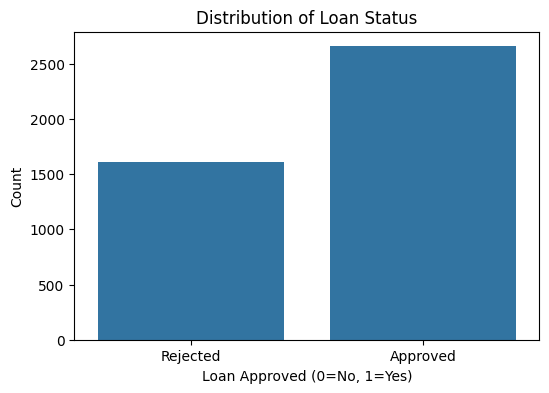

In [34]:
plt.figure(figsize=(6, 4))
sns.countplot(x='loan_status_ Approved', data=df)
plt.title('Distribution of Loan Status')
plt.xlabel('Loan Approved (0=No, 1=Yes)')
plt.ylabel('Count')
plt.xticks(ticks=[0, 1], labels=['Rejected', 'Approved'])
plt.show()

### CIBIL Score Distribution by Loan Status

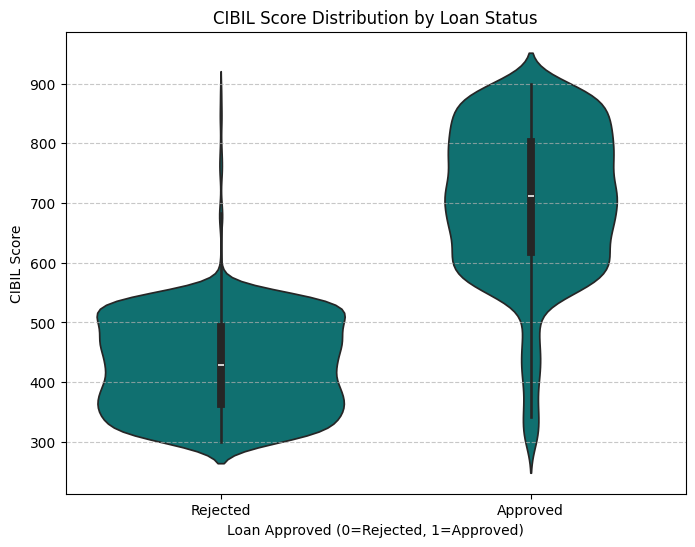

In [59]:
plt.figure(figsize=(8, 6))
sns.violinplot(x='loan_status_ Approved', y='cibil_score', data=df,color='teal')
plt.title('CIBIL Score Distribution by Loan Status')
plt.xlabel('Loan Approved (0=Rejected, 1=Approved)')
plt.ylabel('CIBIL Score')
plt.xticks(ticks=[0, 1], labels=['Rejected', 'Approved'])
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

### Impact of Financial Features on Loan Status

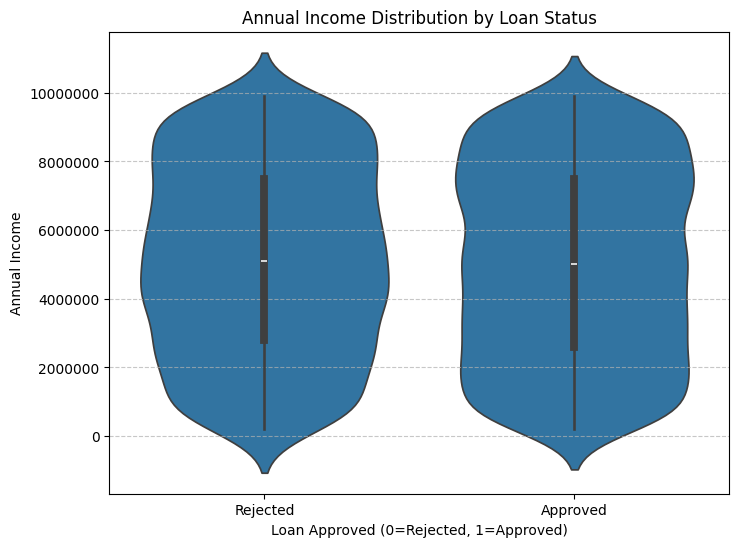

In [36]:
plt.figure(figsize=(8, 6))
sns.violinplot(x='loan_status_ Approved', y='income_annum', data=df)
plt.title('Annual Income Distribution by Loan Status')
plt.xlabel('Loan Approved (0=Rejected, 1=Approved)')
plt.ylabel('Annual Income')
plt.xticks(ticks=[0, 1], labels=['Rejected', 'Approved'])
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.ticklabel_format(style='plain', axis='y') # Prevent scientific notation for large numbers
plt.show()

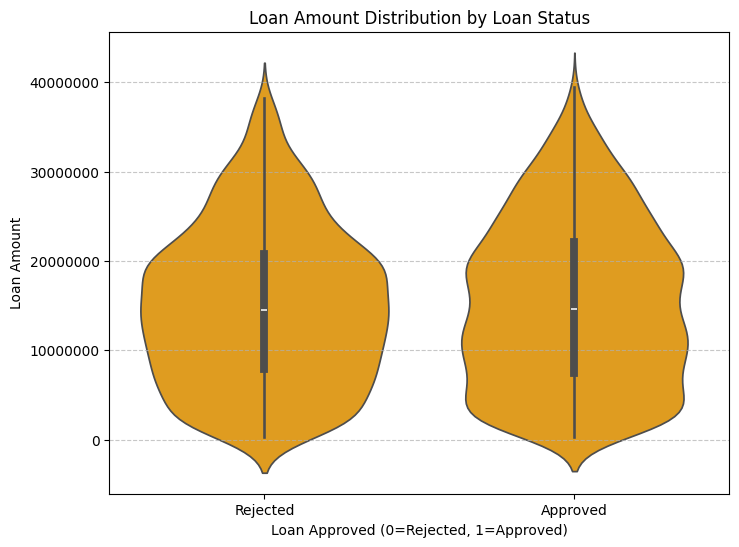

In [56]:
plt.figure(figsize=(8, 6))
sns.violinplot(x='loan_status_ Approved', y='loan_amount', data=df,color='orange')
plt.title('Loan Amount Distribution by Loan Status')
plt.xlabel('Loan Approved (0=Rejected, 1=Approved)')
plt.ylabel('Loan Amount')
plt.xticks(ticks=[0, 1], labels=['Rejected', 'Approved'])
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.ticklabel_format(style='plain', axis='y') # Prevent scientific notation for large numbers
plt.show()

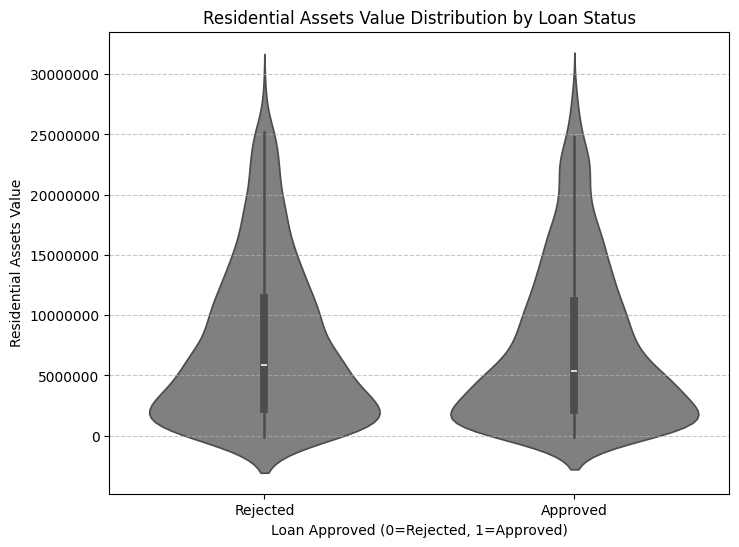

In [55]:
plt.figure(figsize=(8, 6))
sns.violinplot(x='loan_status_ Approved', y='residential_assets_value', data=df,color='grey')
plt.title('Residential Assets Value Distribution by Loan Status')
plt.xlabel('Loan Approved (0=Rejected, 1=Approved)')
plt.ylabel('Residential Assets Value')
plt.xticks(ticks=[0, 1], labels=['Rejected', 'Approved'])
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.ticklabel_format(style='plain', axis='y')
plt.show()

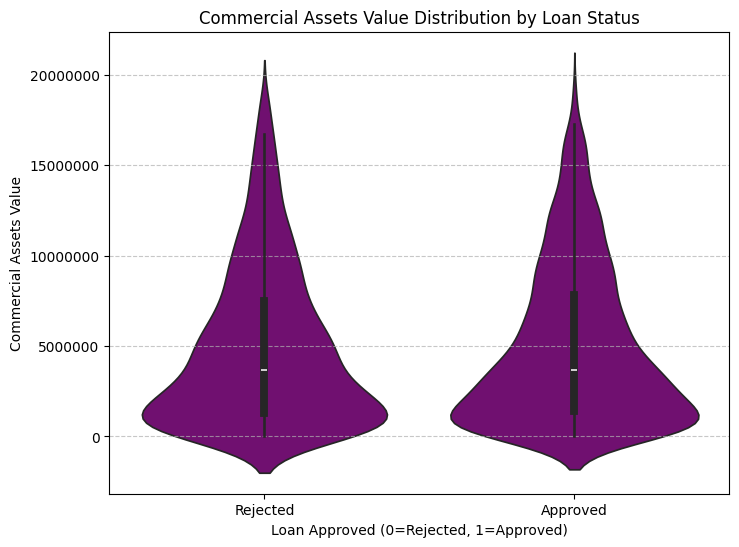

In [54]:
plt.figure(figsize=(8, 6))
sns.violinplot(x='loan_status_ Approved', y='commercial_assets_value', data=df,color='purple')
plt.title('Commercial Assets Value Distribution by Loan Status')
plt.xlabel('Loan Approved (0=Rejected, 1=Approved)')
plt.ylabel('Commercial Assets Value')
plt.xticks(ticks=[0, 1], labels=['Rejected', 'Approved'])
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.ticklabel_format(style='plain', axis='y')
plt.show()

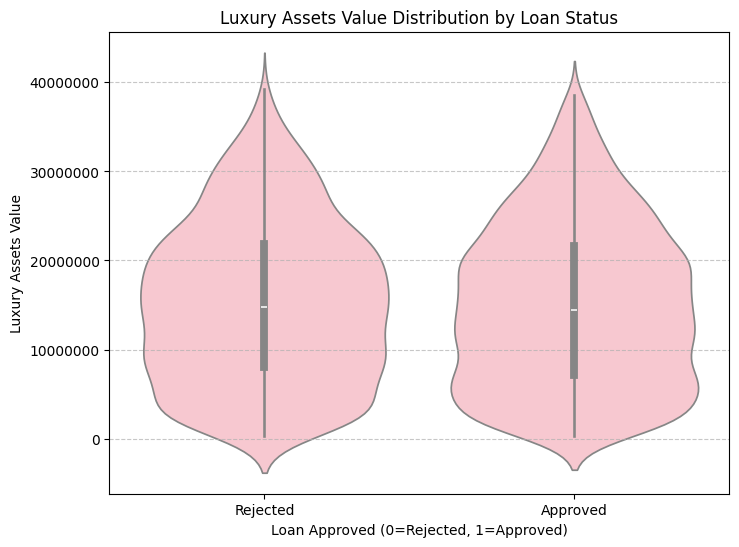

In [53]:
plt.figure(figsize=(8, 6))
sns.violinplot(x='loan_status_ Approved', y='luxury_assets_value', data=df, color ='pink')
plt.title('Luxury Assets Value Distribution by Loan Status')
plt.xlabel('Loan Approved (0=Rejected, 1=Approved)')
plt.ylabel('Luxury Assets Value')
plt.xticks(ticks=[0, 1], labels=['Rejected', 'Approved'])
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.ticklabel_format(style='plain', axis='y')
plt.show()

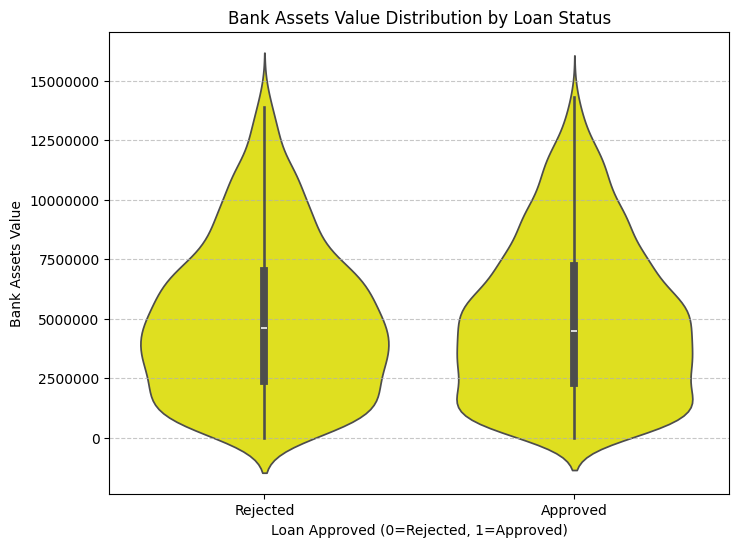

In [57]:
plt.figure(figsize=(8, 6))
sns.violinplot(x='loan_status_ Approved', y='bank_asset_value', data=df,color='yellow')
plt.title('Bank Assets Value Distribution by Loan Status')
plt.xlabel('Loan Approved (0=Rejected, 1=Approved)')
plt.ylabel('Bank Assets Value')
plt.xticks(ticks=[0, 1], labels=['Rejected', 'Approved'])
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.ticklabel_format(style='plain', axis='y')
plt.show()

### Categorical Feature Impact on Loan Status

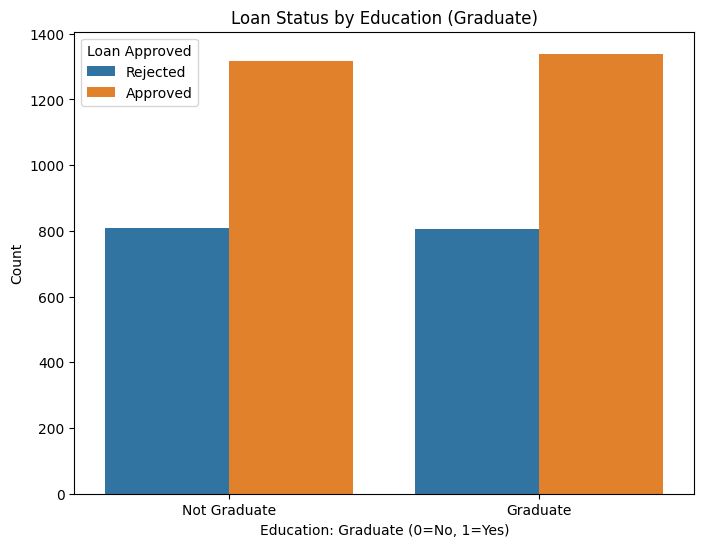

In [46]:
plt.figure(figsize=(8, 6))
sns.countplot(x='education_ Graduate', hue='loan_status_ Approved', data=df)
plt.title('Loan Status by Education (Graduate)')
plt.xlabel('Education: Graduate (0=No, 1=Yes)')
plt.ylabel('Count')
plt.xticks(ticks=[0, 1], labels=['Not Graduate', 'Graduate'])
plt.legend(title='Loan Approved', labels=['Rejected', 'Approved'])
plt.show()

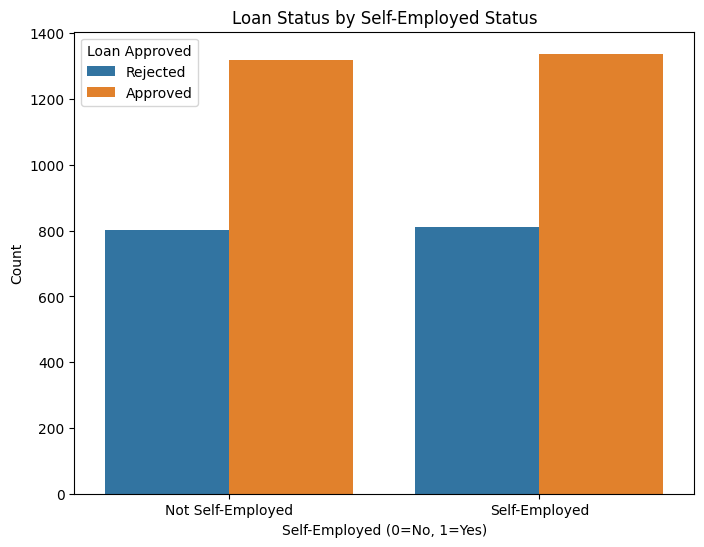

In [47]:
plt.figure(figsize=(8, 6))
sns.countplot(x='self_employed_ Yes', hue='loan_status_ Approved', data=df)
plt.title('Loan Status by Self-Employed Status')
plt.xlabel('Self-Employed (0=No, 1=Yes)')
plt.ylabel('Count')
plt.xticks(ticks=[0, 1], labels=['Not Self-Employed', 'Self-Employed'])
plt.legend(title='Loan Approved', labels=['Rejected', 'Approved'])
plt.show()

In [20]:
# drop values
df.dropna(inplace=True)

In [21]:
# standard scaling
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
# Note: StandardScaler is initialized here, but will be applied to X_train and X_test separately,
# to keep the target variable unscaled for classification.

In [22]:
from sklearn.model_selection import train_test_split
import pandas as pd
import numpy as np

# Re-initialize df from the CSV to ensure it's unscaled
df_temp = pd.read_csv(path + "/loan_approval_dataset.csv")

# Drop 'loan_id' column (as done in eyRidEaiNXfM)
df_temp.drop(columns=['loan_id'], axis=1, inplace=True)

# Re-identify categorical columns and re-apply get_dummies (as done in Q4y_7PiANov1)
cat_cols_temp = df_temp.select_dtypes(include = ['object']).columns.tolist()
df_processed = pd.get_dummies(df_temp, columns=cat_cols_temp)

# Define y first, ensuring it's an integer type for classification and converting to numpy array
y = df_processed[' loan_status_ Approved'].astype(int).to_numpy()

# Define X by dropping the target columns (note the leading space in column names)
X = df_processed.drop(columns = [' loan_status_ Approved', ' loan_status_ Rejected'])

# Split the data into training and testing sets (unscaled features)
X_train_unscaled, X_test_unscaled, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Now, apply scaling only to the feature sets using the pre-initialized 'scaler'
X_train = scaler.fit_transform(X_train_unscaled)
X_test = scaler.transform(X_test_unscaled)

# Convert scaled arrays back to DataFrames to retain column names
X_train = pd.DataFrame(X_train, columns=X.columns)
X_test = pd.DataFrame(X_test, columns=X.columns)

# Ensure y_train and y_test are numpy arrays of integers for scikit-learn
y_train = y_train.astype(int)
y_test = y_test.astype(int)

In [23]:
# hyperparameter tuning
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier


In [24]:

param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [2,5,10],
    "min_samples_split":[2,5,10],
    "min_samples_leaf":[1,2,4]
}


In [25]:
from sklearn.model_selection import RandomizedSearchCV
random=RandomizedSearchCV(estimator=RandomForestClassifier(),param_distributions=param_grid,cv=5,n_jobs=-1,verbose=2)
random.fit(X_train,y_train)

Fitting 5 folds for each of 10 candidates, totalling 50 fits


RandomizedSearchCV(cv=5, estimator=RandomForestClassifier(), n_jobs=-1,
                   param_distributions={'max_depth': [2, 5, 10],
                                        'min_samples_leaf': [1, 2, 4],
                                        'min_samples_split': [2, 5, 10],
                                        'n_estimators': [100, 200, 300]},
                   verbose=2)

In [26]:
# Display the best parameters and best score
print("Best parameters found by RandomizedSearchCV:")
print(random.best_params_)
print("\nBest score found by RandomizedSearchCV:")
print(random.best_score_)

Best parameters found by RandomizedSearchCV:
{'n_estimators': 100, 'min_samples_split': 5, 'min_samples_leaf': 4, 'max_depth': 10}

Best score found by RandomizedSearchCV:
0.977745241581259


In [65]:
# Get the best estimator from RandomizedSearchCV
best_rf_model = random.best_estimator_

# Make predictions on the test set
y_pred = best_rf_model.predict(X_test)
print(y_pred)

# Make predictions on the train set
y_pred= best_rf_model.predict(X_train)
print(y_pred)

[0 1 0 1 1 1 1 0 1 0 0 1 1 0 0 1 1 1 0 0 1 0 0 0 1 1 1 1 1 0 1 0 0 1 0 0 1
 1 1 0 0 1 1 1 1 1 1 1 1 0 1 0 0 1 1 1 1 1 0 1 1 1 0 0 0 1 1 1 1 1 1 1 1 1
 0 1 0 1 1 1 0 0 0 1 0 0 1 1 0 0 1 0 1 0 0 1 0 1 1 1 1 0 1 0 0 1 0 1 1 1 1
 1 0 0 0 1 1 1 1 1 0 1 0 0 1 1 1 0 1 1 1 0 1 0 1 1 1 0 1 1 1 1 1 0 1 1 0 1
 0 1 1 1 0 0 1 1 1 0 1 1 0 1 1 1 0 1 1 1 0 1 1 0 1 1 0 1 1 0 1 0 0 1 0 0 0
 1 1 1 0 1 1 0 0 0 1 1 0 1 1 1 0 0 0 0 0 0 1 1 1 1 1 0 0 1 1 1 0 1 1 1 1 1
 1 0 1 1 1 1 1 0 0 0 1 0 1 1 1 1 0 1 0 0 1 1 1 0 0 0 0 1 1 1 1 1 0 0 0 1 0
 1 1 1 1 1 1 1 1 0 0 1 1 1 0 1 1 1 1 0 1 1 0 0 1 1 1 1 1 0 0 1 1 1 0 1 1 1
 1 0 0 0 0 0 1 1 0 1 1 1 1 1 1 0 1 1 1 1 1 1 0 1 1 1 1 1 1 0 1 0 0 0 1 0 1
 1 1 0 0 1 1 1 1 1 1 1 1 0 0 1 1 0 1 1 0 0 1 1 1 0 0 0 1 0 1 1 0 0 0 1 1 1
 1 0 1 0 0 0 0 0 1 1 1 0 1 0 1 1 1 1 1 1 0 1 1 1 1 0 1 0 1 1 0 1 0 1 1 1 0
 0 1 1 0 1 1 1 1 0 0 0 0 1 1 0 0 1 1 1 0 1 1 1 0 1 1 1 0 0 0 0 1 1 0 1 1 0
 1 1 1 1 1 1 0 1 0 1 0 1 1 1 1 1 1 1 0 0 1 1 0 0 0 0 1 1 1 0 1 1 0 0 1 1 1
 1 0 1 1 1 1 1 0 1 1 0 0 

In [28]:
from sklearn.metrics import classification_report, accuracy_score

# Evaluate the model
print("Classification Report on Test Data:")
print(classification_report(y_test, y_pred))

print("\nAccuracy Score on Test Data:")
print(accuracy_score(y_test, y_pred))


Classification Report on Test Data:
              precision    recall  f1-score   support

           0       0.98      0.96      0.97       318
           1       0.97      0.99      0.98       536

    accuracy                           0.98       854
   macro avg       0.98      0.97      0.97       854
weighted avg       0.98      0.98      0.98       854


Accuracy Score on Test Data:
0.9765807962529274


In [29]:
accuracy_score(y_train,best_rf_model.predict(X_train))

0.99502196193265

In [30]:
model=random.best_estimator_

In [31]:
# building random forest model
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


In [50]:
# train
model=RandomForestClassifier(n_estimators=300,min_samples_split=5,min_samples_leaf=1,max_depth=2)
model.fit(X_train,y_train)


RandomForestClassifier(max_depth=2, min_samples_split=5, n_estimators=300)

In [67]:
# Evaluate the model
print("Classification Report on Test Data:")
print(classification_report(y_test, y_pred))

Classification Report on Test Data:
              precision    recall  f1-score   support

           0       0.92      0.99      0.95       318
           1       0.99      0.95      0.97       536

    accuracy                           0.96       854
   macro avg       0.96      0.97      0.96       854
weighted avg       0.97      0.96      0.96       854



In [70]:
import joblib
joblib.dump(model, 'loan_approval_model.pkl')

['loan_approval_model.pkl']